In [1]:
import os, argparse, typing
os.chdir("/home/wergillius/Project/PINN_dynamics")

import numpy as np
import pandas as pd
import torch 

from PINN import models as models
from PINN import reader 
from PINN import functions as fns

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.
import decipher as dc
import scvi

In [2]:
dc.pl.activate_journal_quality()

In [22]:
# load data
ery_mk_ad = sc.read_h5ad("data/ery_mk.h5ad")
pt_path = "data/HSPC_mk_ery.pt" 
D = torch.load(pt_path)

In [23]:
ery_mk_ad

AnnData object with n_obs × n_vars = 22740 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [4]:
color_palette = None
ery_mk_ad.uns['color_palette'] = color_palette

In [5]:
ery_mk_ad.layers['Normed_X']=ery_mk_ad.X.copy()

In [6]:
ery_mk_ad.X = ery_mk_ad.layers['Rawcount']

In [16]:
ery_mk_ad.obs.columns
# ['batch_plate_sorted', 'sample.name', 'sample_id', '10xsample_description', 'biosample_id']

Index(['n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores',
       'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin',
       'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid',
       'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id',
       'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound',
       'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days',
       'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase',
       'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted',
       'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel',
       'sort_method', 'sample.name', 'population', 'sex', 'countfolder',
       'batch_plate_sorted', 'data_type', 'sex_combined', 'longname',
       'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot',
       'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR',
       'log_density_at_E3', 'log_density_at_E7', 'log_density

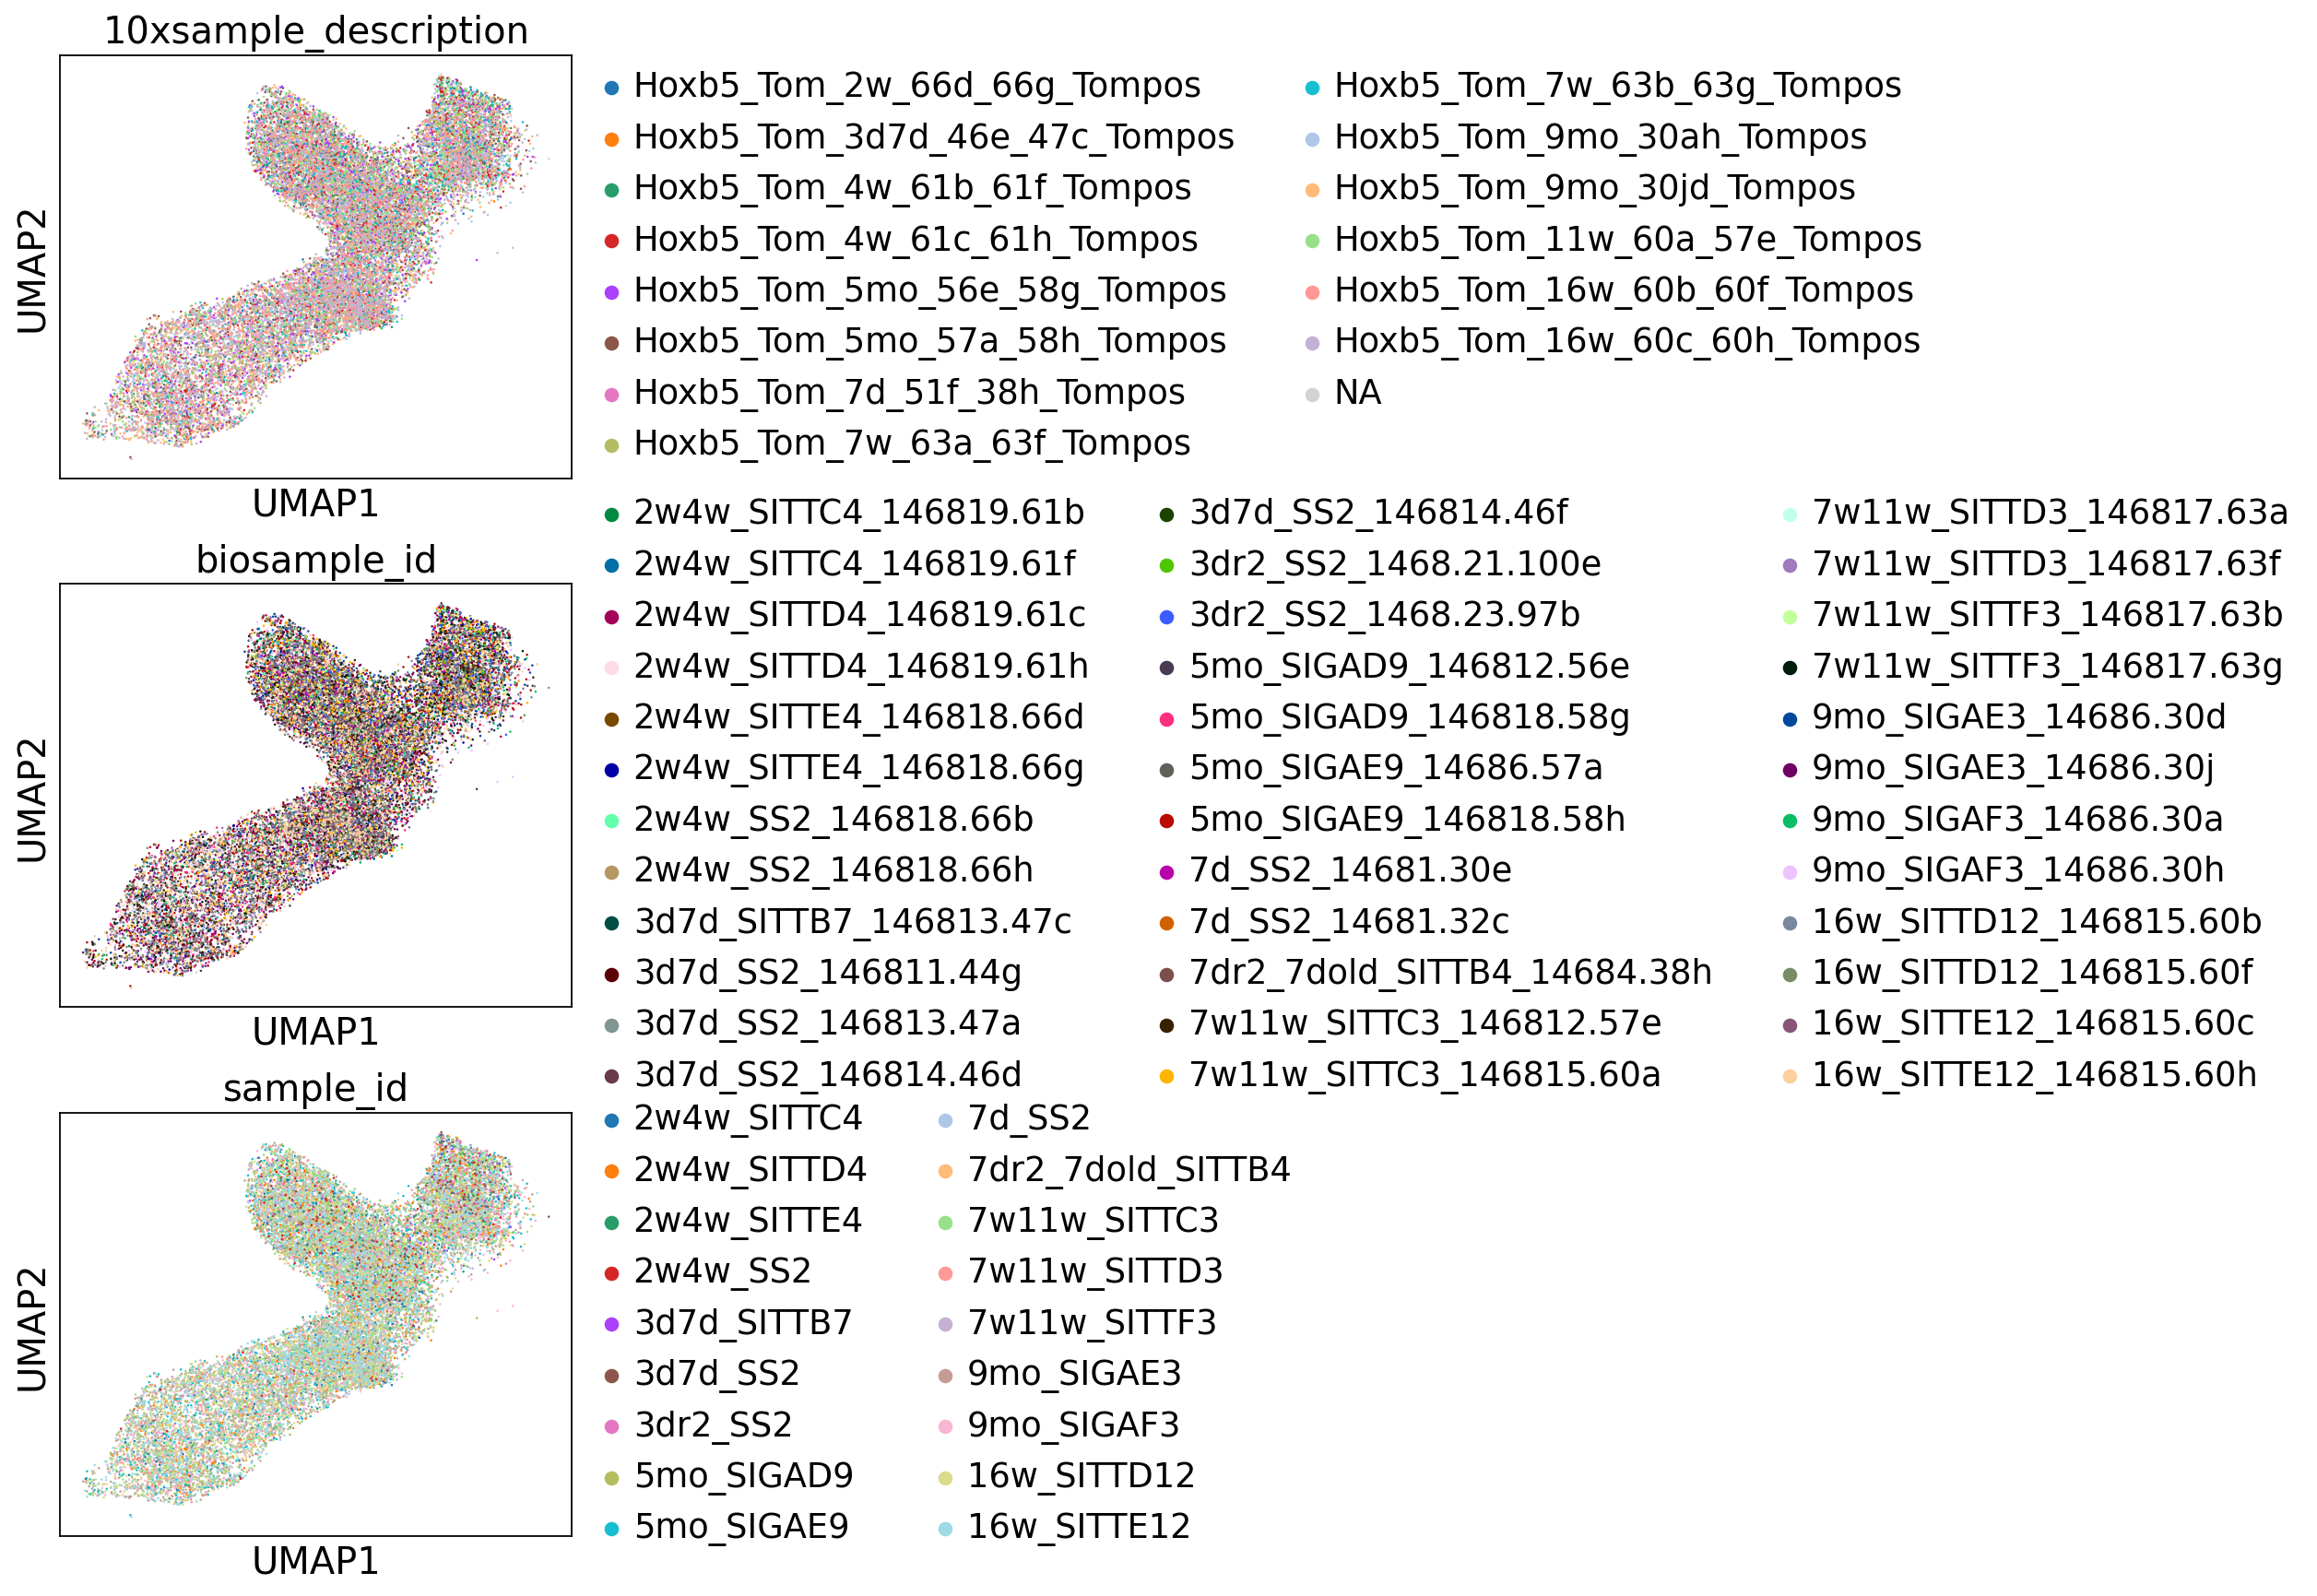

In [17]:
sc.pl.umap(ery_mk_ad, color=['10xsample_description', 'biosample_id', 'sample_id'], ncols=1)

# scvi

In [19]:
scvi.model.SCVI.setup_anndata(ery_mk_ad, layer="Rawcount", batch_key="biosample_id")

In [20]:
scvi_model = scvi.model.SCVI(ery_mk_ad, n_layers=2, n_latent=16)

In [21]:
scvi_model.train(max_epochs = 1000,
    accelerator = "gpu",
    devices = [2],
    early_stopping=True
    )

INFO: GPU available: True (cuda), used: True
2024-07-09 22:57:22,255 | INFO : GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2024-07-09 22:57:22,305 | INFO : TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
2024-07-09 22:57:22,305 | INFO : IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
2024-07-09 22:57:22,306 | INFO : HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
2024-07-09 22:57:23,813 | INFO : LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Epoch 178/1000:  18%|█▊        | 178/1000 [04:25<20:24,  1.49s/it, v_num=1, train_loss_step=762, train_loss_epoch=836]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 866.379. Signaling Trainer to stop.


In [24]:
ery_mk_ad.obsm["X_scvi"] = scvi_model.get_latent_representation()

In [25]:
sc.pp.neighbors(ery_mk_ad, n_neighbors=50, use_rep='X_scvi')
sc.tl.umap(ery_mk_ad)

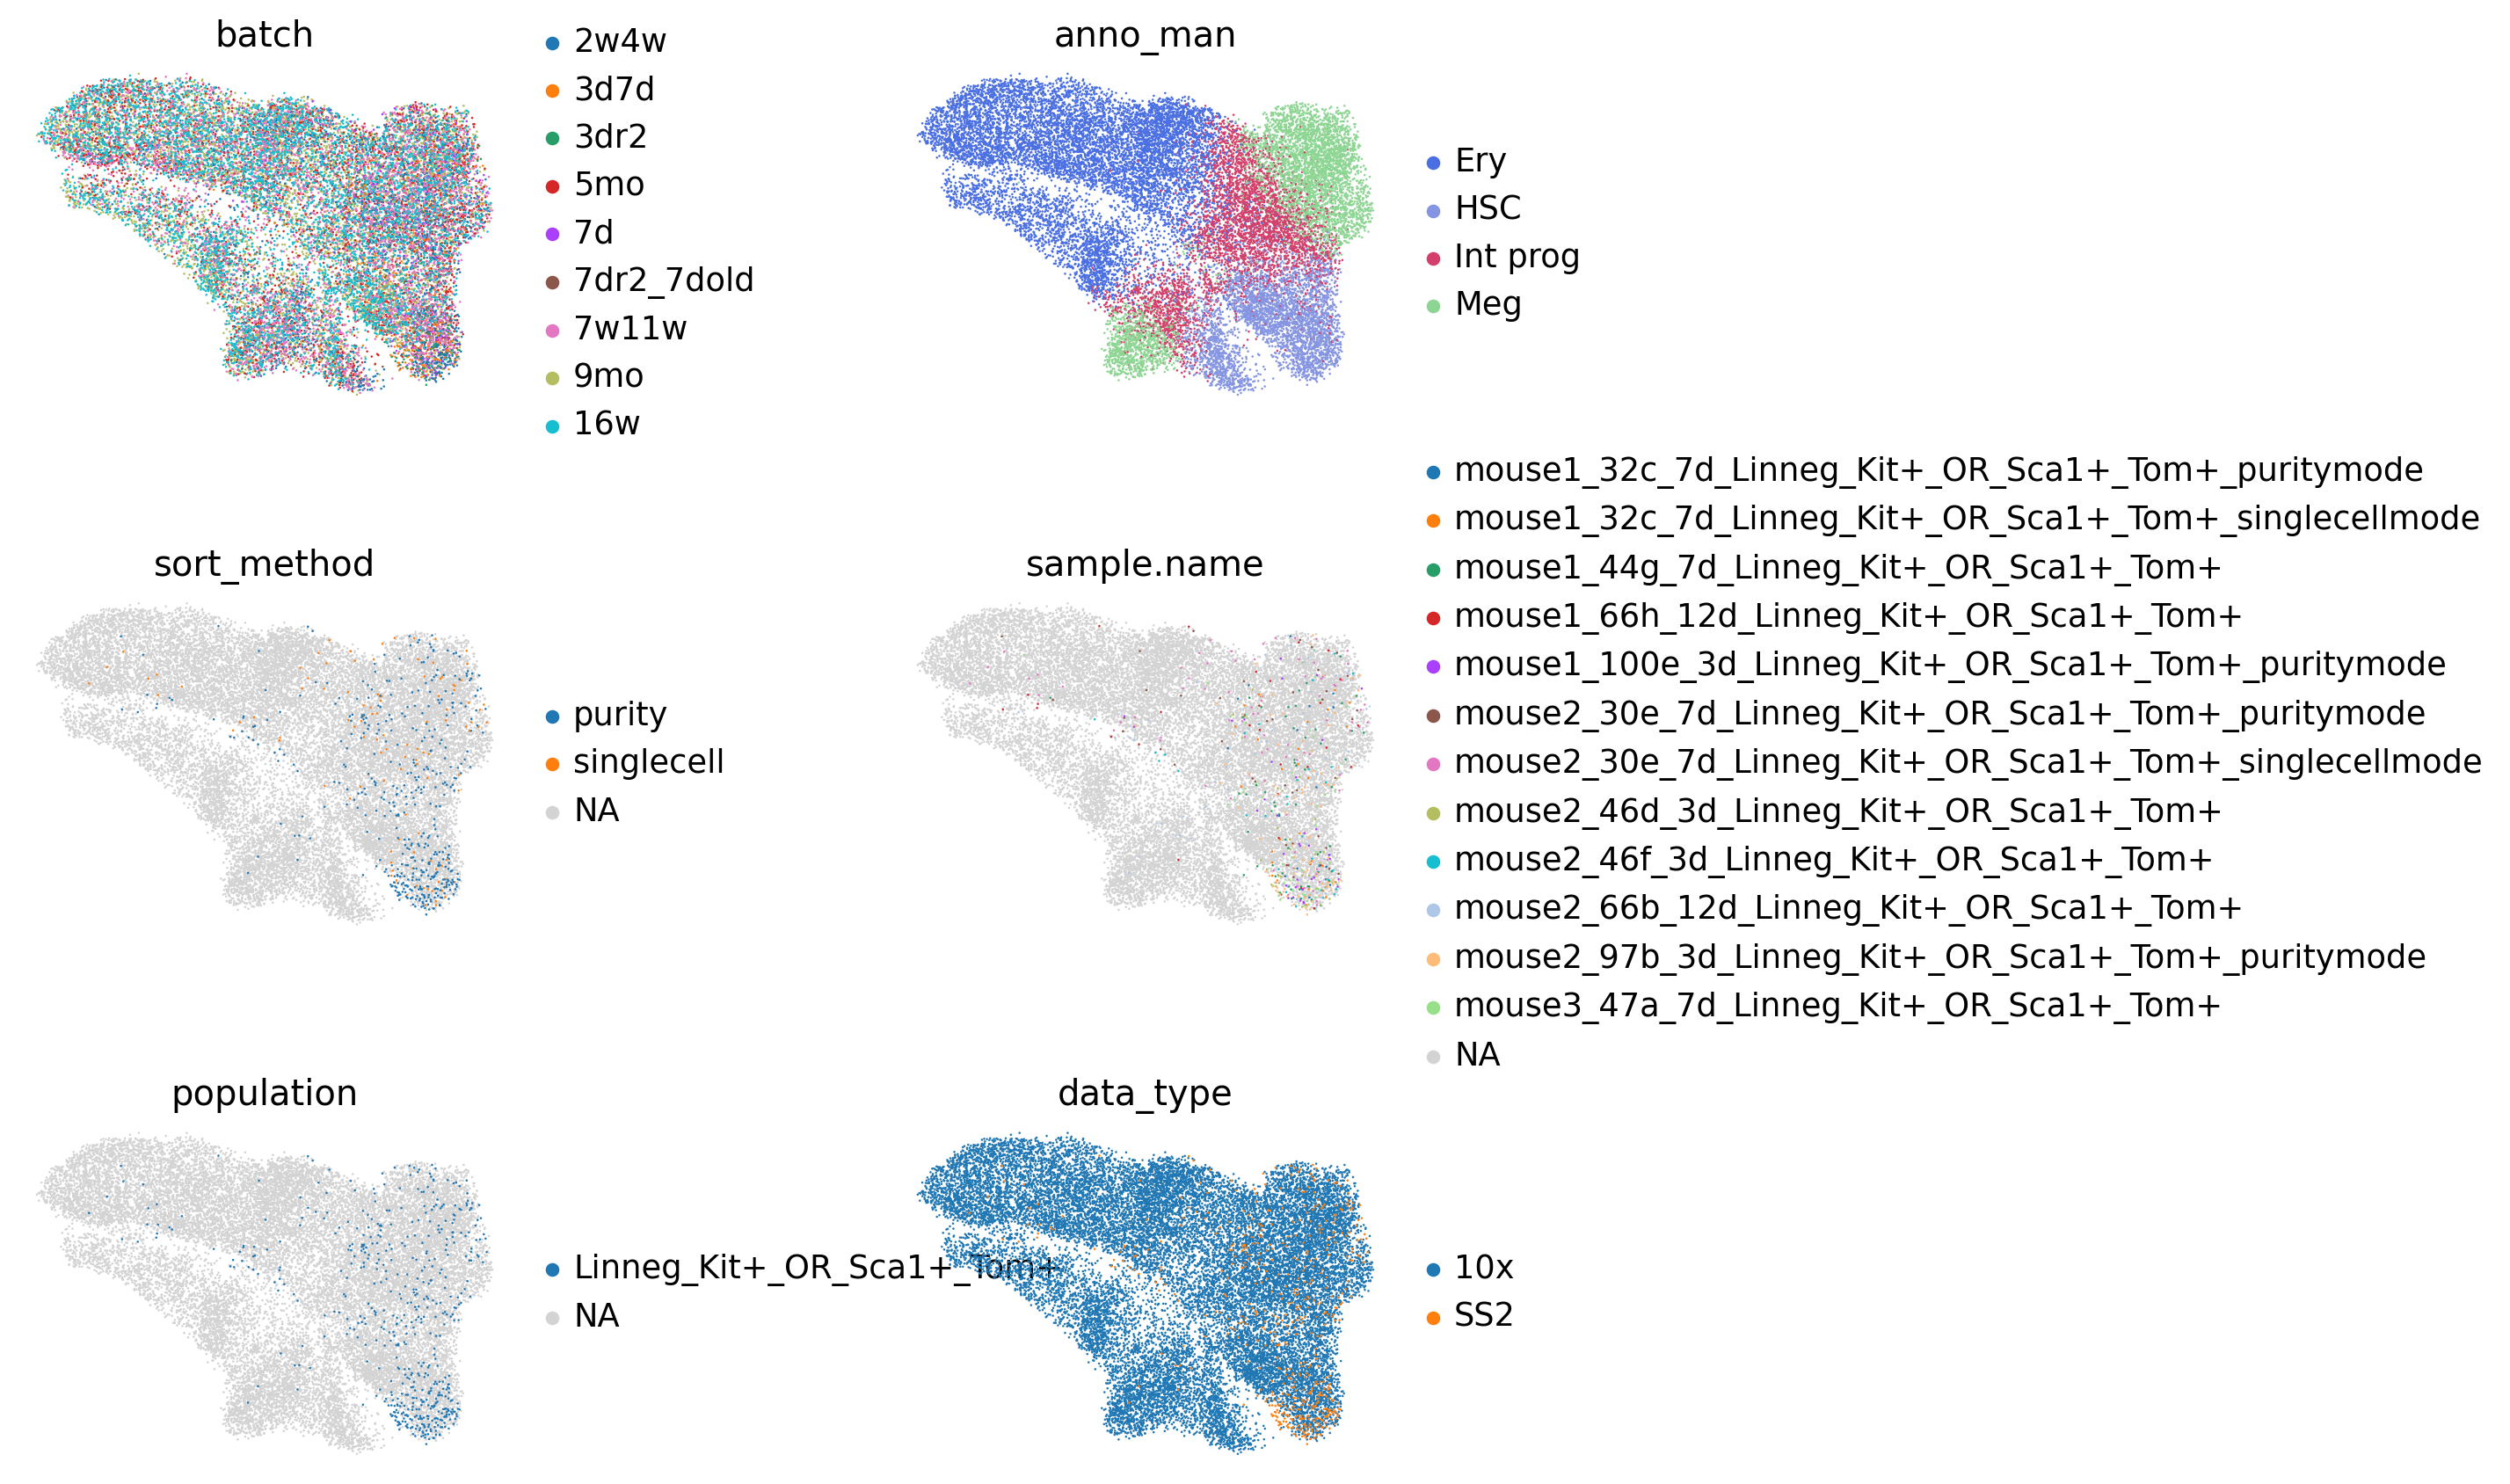

In [37]:
sc.pl.umap(ery_mk_ad, color=['batch', 'anno_man', 'sort_method', 'sample.name', 'population', 'data_type'],
            frameon=False,
           ncols=2, hspace=0.5, wspace=0.6)